# Step 1 — Timestamp Matching

## What this step does

The SCExAO/FIRST-PL instrument uses **two cameras running at different speeds**:

| Camera | Role | Speed | Data |
|--------|------|-------|------|
| **PSFcam** (Palila) | Records the telescope PSF | Fast (e.g. 20 000 frames) | 40×40 px crop |
| **PLcam** (FIRST-PL) | Records fiber spectra | Slow (e.g. 10 000 frames) | 2000×500 px |

The two cameras are **not synchronized** — each saves FITS files independently with separate timestamp files.

**Step 1** matches them in time: for every slow-camera (PLcam) frame, it finds which fast-camera (PSFcam) frames fell within that exposure interval and averages them into a single representative PSF frame. The output is one H5 file containing N averaged PSFcam frames, one per PLcam frame.

```
PSFcam frames:  [--1--][--2--][--3--]...[--20000--]
PLcam frames :  [--------A---------][--------B---------]...

Result:  averaged PSF_A = mean(frames 1..6)
         averaged PSF_B = mean(frames 7..12)
         ...
```

**Output**: `step1_fastcam.h5` — one matched PSFcam frame per PLcam timestamp.

## Setup: paths and parameters

Set every parameter as a Python variable first. This makes it easy to see and change what the pipeline is doing.

In [1]:
import os

# ── Directory of this notebook ───────────────────────────────────────────────
TUTORIAL_DIR = os.path.dirname(os.path.abspath('__file__'))
# If the above gives the wrong path, replace with:
# TUTORIAL_DIR = '/absolute/path/to/PLred-dev/PLred/tutorials'

# ── Input data ───────────────────────────────────────────────────────────────
FASTCAM_DIR   = os.path.join(TUTORIAL_DIR, 'data', 'fastcam')   # PSFcam FITS + timestamps
SLOWCAM_DIR   = os.path.join(TUTORIAL_DIR, 'data', 'slowcam')   # PLcam timestamps
FASTCAM_DARK  = os.path.join(FASTCAM_DIR, 'dark.fits')          # PSFcam dark frame

# ── Output ───────────────────────────────────────────────────────────────────
OUTPUT_DIR    = os.path.join(TUTORIAL_DIR, 'tutorial_output_new')
OUTPUT_NAME   = 'step1_fastcam'   # output file will be step1_fastcam.h5

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Observation parameters ───────────────────────────────────────────────────
OBS_DATE      = '20240917'   # date of observation (YYYYMMDD)
START_TIME    = '15:05:10'   # start of observation window (HH:MM:SS)
END_TIME      = '15:05:11'   # end of observation window (HH:MM:SS)

# ── Instrument options ────────────────────────────────────────────────────────
PSFCAM_IS_FAST            = True    # True: Palila is the fast camera (normal setup)
CROP_WIDTH                = 20      # crop PSFcam frames to (2*CROP_WIDTH) × (2*CROP_WIDTH)
APPLY_DEAD_TIME_CORRECTION = True   # correct for dead time between FITS files

print('Input fast-cam dir :', FASTCAM_DIR)
print('Input slow-cam dir :', SLOWCAM_DIR)
print('Output dir         :', OUTPUT_DIR)
print('Output file        :', os.path.join(OUTPUT_DIR, OUTPUT_NAME + '.h5'))

Input fast-cam dir : /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/data/fastcam
Input slow-cam dir : /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/data/slowcam
Output dir         : /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/tutorial_output_new
Output file        : /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/tutorial_output_new/step1_fastcam.h5


## Inspect the input data

Each camera saves:
- **FITS files** — the actual pixel data (one file per chunk of frames)
- **Timestamp files** (`.txt`) — one row per frame: `[frame_index, unix_timestamp]`

Let's confirm the files are there.

In [2]:
import glob

fc_fits = sorted(glob.glob(os.path.join(FASTCAM_DIR, '*.fits')))
fc_txt  = sorted(glob.glob(os.path.join(FASTCAM_DIR, '*.txt')))
sc_txt  = sorted(glob.glob(os.path.join(SLOWCAM_DIR, '*.txt')))
sc_fits = sorted(glob.glob(os.path.join(SLOWCAM_DIR, '*.fits')))

print(f'PSFcam FITS files : {len(fc_fits)}')
for f in fc_fits: print(f'  {os.path.basename(f)}')

print(f'\nPSFcam timestamps : {len(fc_txt)}')
for f in fc_txt: print(f'  {os.path.basename(f)}')

print(f'\nPLcam timestamps  : {len(sc_txt)}')
for f in sc_txt: print(f'  {os.path.basename(f)}')

print(f'\nPLcam FITS files  : {len(sc_fits)}  (used in Step 2, not here)')

PSFcam FITS files : 2
  cropped_palila_15:05:10.002607418.fits
  dark.fits

PSFcam timestamps : 1
  cropped_palila_15:05:10.002607418.txt

PLcam timestamps  : 1
  cropped_firstpl_15:05:17.315924371.txt

PLcam FITS files  : 2  (used in Step 2, not here)


In [3]:
import numpy as np
from astropy.io import fits

# Peek at one timestamp file
ts_data = np.loadtxt(fc_txt[0])
print(f'Timestamp file columns : frame_index, unix_time')
print(f'First 5 rows:')
print(ts_data[:5])

# Peek at the PSFcam FITS
with fits.open(fc_fits[0]) as hdul:
    fc_shape = hdul[0].data.shape
print(f'\nPSFcam FITS shape : {fc_shape}  (n_frames, height, width)')

# Show the dark frame
dark = fits.getdata(FASTCAM_DARK)
print(f'PSFcam dark shape : {dark.shape}')

Timestamp file columns : frame_index, unix_time
First 5 rows:
[[0.00000000e+00 1.55176050e+07 7.11474967e+00 1.72658552e+09
  1.72658552e+09 1.55176050e+07 0.00000000e+00]
 [1.00000000e+00 1.55176060e+07 7.12031054e+00 1.72658552e+09
  1.72658552e+09 1.55176060e+07 0.00000000e+00]
 [2.00000000e+00 1.55176070e+07 7.12550235e+00 1.72658552e+09
  1.72658552e+09 1.55176070e+07 0.00000000e+00]
 [3.00000000e+00 1.55176080e+07 7.13080049e+00 1.72658552e+09
  1.72658552e+09 1.55176080e+07 0.00000000e+00]
 [4.00000000e+00 1.55176090e+07 7.13602495e+00 1.72658552e+09
  1.72658552e+09 1.55176090e+07 0.00000000e+00]]

PSFcam FITS shape : (235, 256, 320)  (n_frames, height, width)
PSFcam dark shape : (256, 320)


## Run timestamp matching

`script_match_timestamps` takes a config file path. We write the config from our Python variables — this way all parameters are visible and you can edit them above without touching the config file by hand.

In [4]:
import configobj

# Build config from Python variables
config = configobj.ConfigObj()
config.filename = os.path.join(OUTPUT_DIR, 'step1_config.ini')

config['Fastcam'] = {
    'obs_date'   : OBS_DATE,
    'start_time' : START_TIME,
    'end_time'   : END_TIME,
    'dark_file'  : FASTCAM_DARK,
    'path'       : FASTCAM_DIR + os.sep,
}
config['Slowcam'] = {
    'timestamp_dir' : SLOWCAM_DIR + os.sep,
}
config['Output'] = {
    'outname'  : OUTPUT_DIR + os.sep,
    'filename' : OUTPUT_NAME,
}
config['Options'] = {
    'verbose'                     : 'True',
    'show_plot'                   : 'False',    # set True to show interactive plot
    'crop_width'                  : str(CROP_WIDTH),
    'apply_dead_time_correction'  : str(APPLY_DEAD_TIME_CORRECTION),
    'psfcam_is_fast'              : str(PSFCAM_IS_FAST),
}
config.write()

print('Config written to:', config.filename)

Config written to: /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/tutorial_output_new/step1_config.ini


number of files found: 1
fastcam timestampfiles: ['/Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/data/fastcam/cropped_palila_15:05:10.002607418.txt']
slowcam timestampfiles: ['/Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/data/slowcam/cropped_firstpl_15:05:17.315924371.txt']
total slowcam images: 49
Applied dead-time correction using frame end times


100%|██████████| 49/49 [00:00<00:00, 187861.88it/s]


PSFcam=fastcam — saving cropped frames [108:148, 140:180]
reading fastcam file /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/data/fastcam/cropped_palila_15:05:10.002607418.fits


100%|██████████| 49/49 [00:00<00:00, 5328.93it/s]

frame 37  frac 0.4930
frame 38  frac 1.0000
frame 39  frac 1.0000
frame 40  frac 1.0000
frame 41  frac 0.2591
frame 41  frac 0.7409
frame 42  frac 1.0000
frame 43  frac 1.0000
frame 44  frac 1.0000
frame 45  frac 0.0141
frame 45  frac 0.9859
frame 46  frac 1.0000
frame 47  frac 1.0000
frame 48  frac 0.7627
frame 48  frac 0.2373
frame 49  frac 1.0000
frame 50  frac 1.0000
frame 51  frac 1.0000
frame 52  frac 0.5160
frame 52  frac 0.4840
frame 53  frac 1.0000
frame 54  frac 1.0000
frame 55  frac 1.0000
frame 56  frac 0.2640
frame 56  frac 0.7360
frame 57  frac 1.0000
frame 58  frac 1.0000
frame 59  frac 1.0000
frame 60  frac 0.0112
frame 60  frac 0.9888
frame 61  frac 1.0000
frame 62  frac 1.0000
frame 63  frac 0.7612
frame 63  frac 0.2388
frame 64  frac 1.0000
frame 65  frac 1.0000
frame 66  frac 1.0000
frame 67  frac 0.5192
frame 67  frac 0.4808
frame 68  frac 1.0000
frame 69  frac 1.0000
frame 70  frac 1.0000
frame 71  frac 0.2749
frame 71  frac 0.7251
frame 72  frac 1.0000
frame 73  

Diagnostics saved to /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/tutorial_output_new/step1_fastcam_diagnostics.png
=== Diagnostic summary: step1_fastcam.h5 ===
fastcam frames:         235  (1 files)
slowcam matched frames: 49
Weight range: [0.0112, 1.0000]  (out-of-range: 0)
w_total: median=3.751  min=3.736  max=3.777

Step 1 complete. Output H5: /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/tutorial_output_new/step1_fastcam.h5


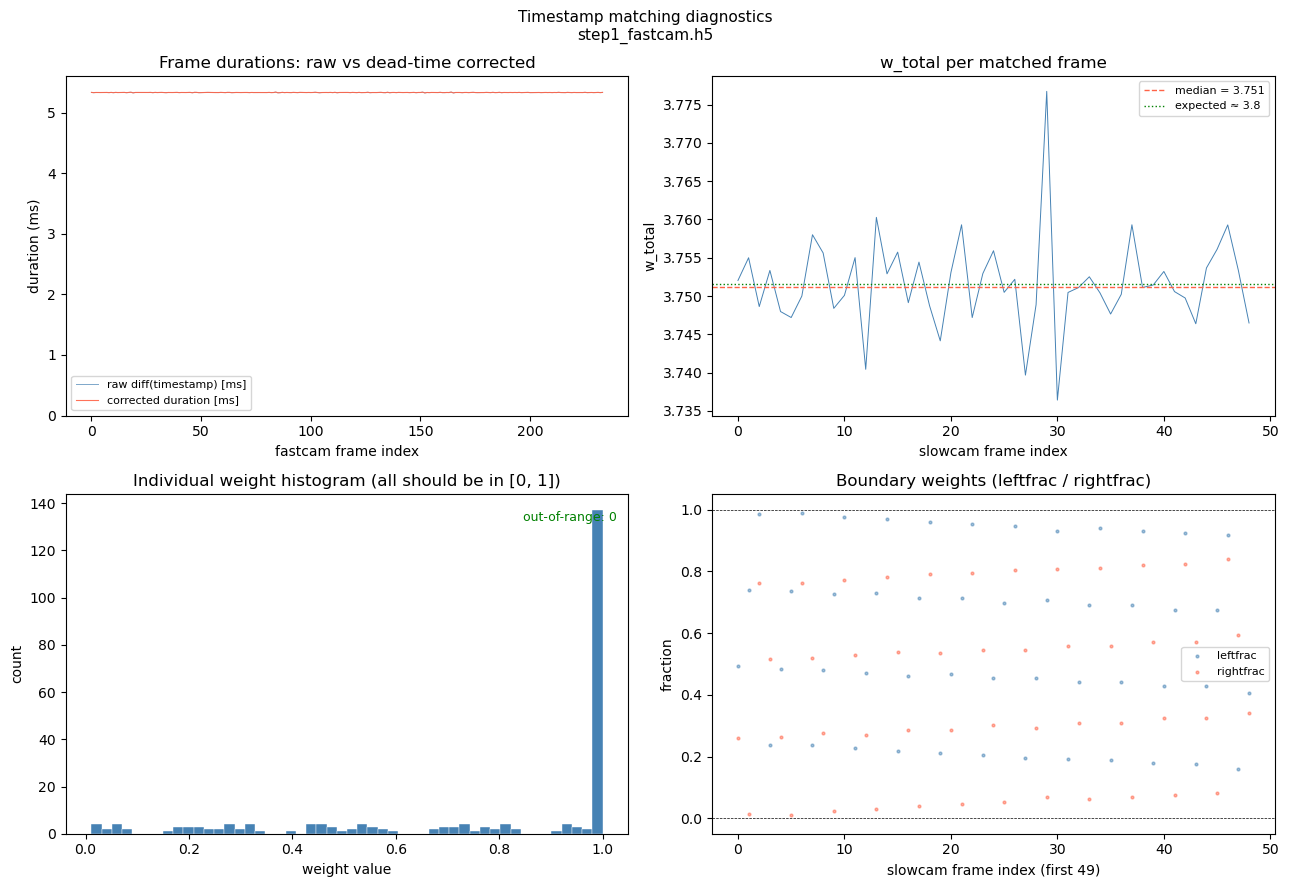

In [5]:
import sys
sys.path.insert(0, os.path.join(TUTORIAL_DIR, '..', '..'))

import PLred.sort as sort

# Run timestamp matching
# This reads the config we just wrote and saves the output H5
output_h5 = sort.script_match_timestamps(config.filename)

print('\nStep 1 complete. Output H5:', output_h5)

## Inspect the output H5

The output contains one row per PLcam frame:
- `frames` — the averaged PSFcam crop (40×40 px) for each timestamp
- `nstacks` — how many PSFcam frames were averaged (quality indicator: higher = more signal)
- `timestamps` — Unix time of each PLcam frame
- `metadata` — JSON with file lists and matching details (used by Step 2)

In [6]:
import h5py, json

output_h5 = os.path.join(OUTPUT_DIR, OUTPUT_NAME + '.h5')

with h5py.File(output_h5, 'r') as f:
    frames     = f['frames'][:]      # shape: (N, h, w)
    nstacks    = f['nstacks'][:]     # shape: (N,)
    timestamps = f['timestamps'][:]  # shape: (N,)
    metadata   = json.loads(f['metadata'][()])

N = len(timestamps)
print(f'N matched frames   : {N}')
print(f'PSFcam frame shape : {frames.shape}  (N, height, width)')
print(f'nstacks range      : [{nstacks.min():.1f}, {nstacks.max():.1f}]  (frames averaged per PLcam frame)')
print(f'Observation span   : {timestamps[-1] - timestamps[0]:.2f} seconds')
print(f'psfcam_is_fast     : {metadata["psfcam_is_fast"]}')

N matched frames   : 49
PSFcam frame shape : (49, 40, 40)  (N, height, width)
nstacks range      : [3.7, 3.8]  (frames averaged per PLcam frame)
Observation span   : 0.96 seconds
psfcam_is_fast     : True


## Visualize: PSFcam frames and diagnostics

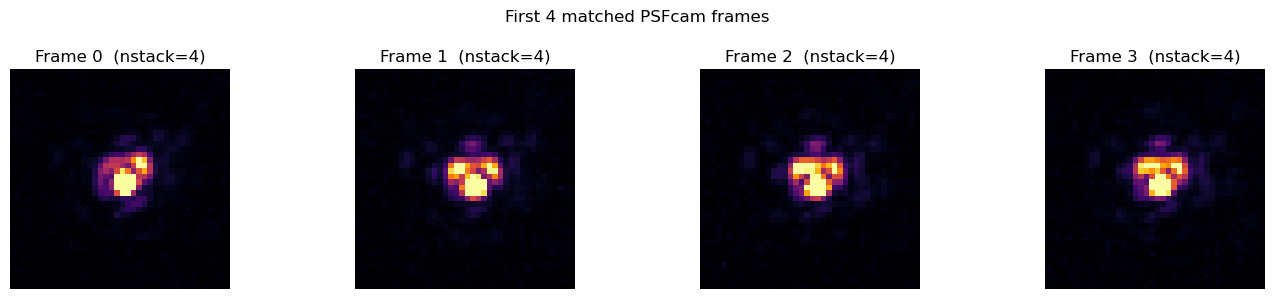

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(14, 3))

# Show first 4 PSFcam frames
for i, ax in enumerate(axes):
    ax.imshow(frames[i], origin='lower', cmap='inferno',
              vmin=np.percentile(frames[i], 5), vmax=np.percentile(frames[i], 99))
    ax.set_title(f'Frame {i}  (nstack={nstacks[i]:.0f})')
    ax.axis('off')

plt.suptitle('First 4 matched PSFcam frames')
plt.tight_layout()
plt.show()

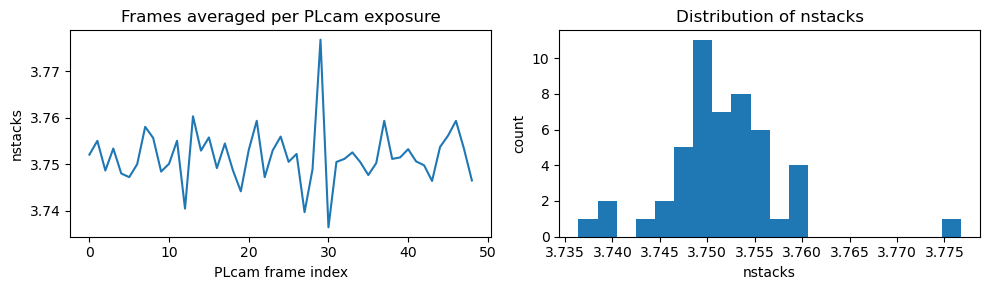

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

# nstacks over time — how many PSFcam frames were averaged per PLcam frame
ax1.plot(nstacks)
ax1.set_xlabel('PLcam frame index')
ax1.set_ylabel('nstacks')
ax1.set_title('Frames averaged per PLcam exposure')

# Histogram of nstacks
ax2.hist(nstacks, bins=20)
ax2.set_xlabel('nstacks')
ax2.set_ylabel('count')
ax2.set_title('Distribution of nstacks')

plt.tight_layout()
plt.show()

Diagnostics saved to /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/tutorial_output_new/step1_fastcam_diagnostics.png
=== Diagnostic summary: step1_fastcam.h5 ===
fastcam frames:         235  (1 files)
slowcam matched frames: 49
Weight range: [0.0112, 1.0000]  (out-of-range: 0)
w_total: median=3.751  min=3.736  max=3.777


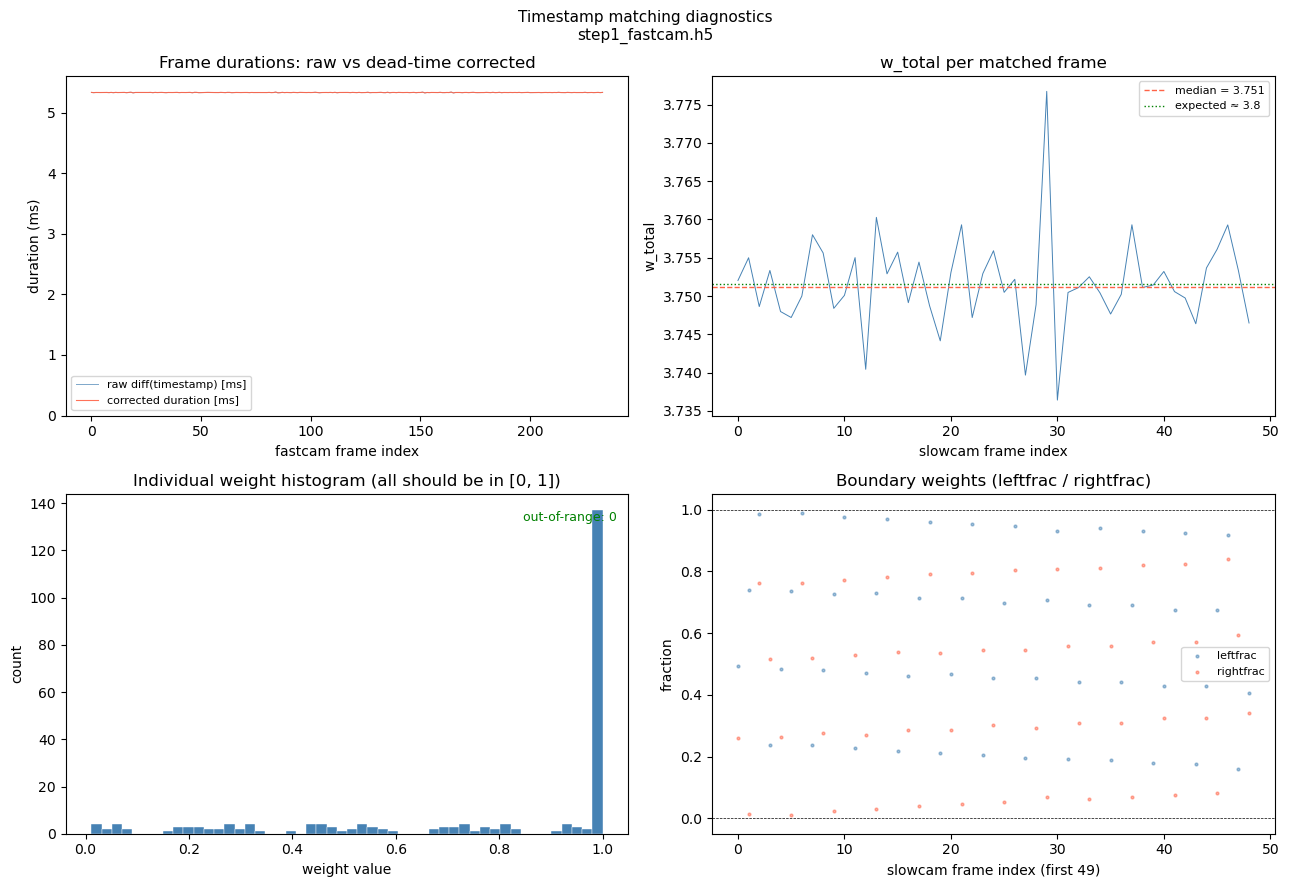

Diagnostics saved to: /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/tutorial_output_new/step1_fastcam_diagnostics.png


In [11]:
# Generate and save the matching diagnostics plot
sort.plot_matching_diagnostics(output_h5)
plt.show()
print('Diagnostics saved to:', output_h5.replace('.h5', '_diagnostics.png'))

## Summary

Step 1 produced `step1_fastcam.h5` with:
- **N matched frames** — one averaged PSFcam frame per PLcam timestamp
- **Metadata** — file paths and matching details needed by Step 2

**Next**: Run `tutorial_step2_ingest.ipynb` to combine this with the PLcam frames into the consolidated "giant H5".

The same step can be run from the command line using a config file and the `pipeline` module.
The config file we wrote (`tutorial_output_new/step1_config.ini`) is exactly the input needed.


number of files found: 1
fastcam timestampfiles: ['/Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/data/fastcam/cropped_palila_15:05:10.002607418.txt']
slowcam timestampfiles: ['/Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/data/slowcam/cropped_firstpl_15:05:17.315924371.txt']
total slowcam images: 49
Applied dead-time correction using frame end times


100%|██████████| 49/49 [00:00<00:00, 70432.11it/s]


PSFcam=fastcam — saving cropped frames [108:148, 140:180]
reading fastcam file /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/data/fastcam/cropped_palila_15:05:10.002607418.fits


100%|██████████| 49/49 [00:00<00:00, 6141.92it/s]

frame 37  frac 0.4930
frame 38  frac 1.0000
frame 39  frac 1.0000
frame 40  frac 1.0000
frame 41  frac 0.2591
frame 41  frac 0.7409
frame 42  frac 1.0000
frame 43  frac 1.0000
frame 44  frac 1.0000
frame 45  frac 0.0141
frame 45  frac 0.9859
frame 46  frac 1.0000
frame 47  frac 1.0000
frame 48  frac 0.7627
frame 48  frac 0.2373
frame 49  frac 1.0000
frame 50  frac 1.0000
frame 51  frac 1.0000
frame 52  frac 0.5160
frame 52  frac 0.4840
frame 53  frac 1.0000
frame 54  frac 1.0000
frame 55  frac 1.0000
frame 56  frac 0.2640
frame 56  frac 0.7360
frame 57  frac 1.0000
frame 58  frac 1.0000
frame 59  frac 1.0000
frame 60  frac 0.0112
frame 60  frac 0.9888
frame 61  frac 1.0000
frame 62  frac 1.0000
frame 63  frac 0.7612
frame 63  frac 0.2388
frame 64  frac 1.0000
frame 65  frac 1.0000
frame 66  frac 1.0000
frame 67  frac 0.5192
frame 67  frac 0.4808
frame 68  frac 1.0000
frame 69  frac 1.0000
frame 70  frac 1.0000
frame 71  frac 0.2749
frame 71  frac 0.7251
frame 72  frac 1.0000
frame 73  

Diagnostics saved to /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/tutorial_output_new/step1_fastcam_diagnostics.png
=== Diagnostic summary: step1_fastcam.h5 ===
fastcam frames:         235  (1 files)
slowcam matched frames: 49
Weight range: [0.0112, 1.0000]  (out-of-range: 0)
w_total: median=3.751  min=3.736  max=3.777


'/Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/tutorial_output_new/step1_fastcam.h5'

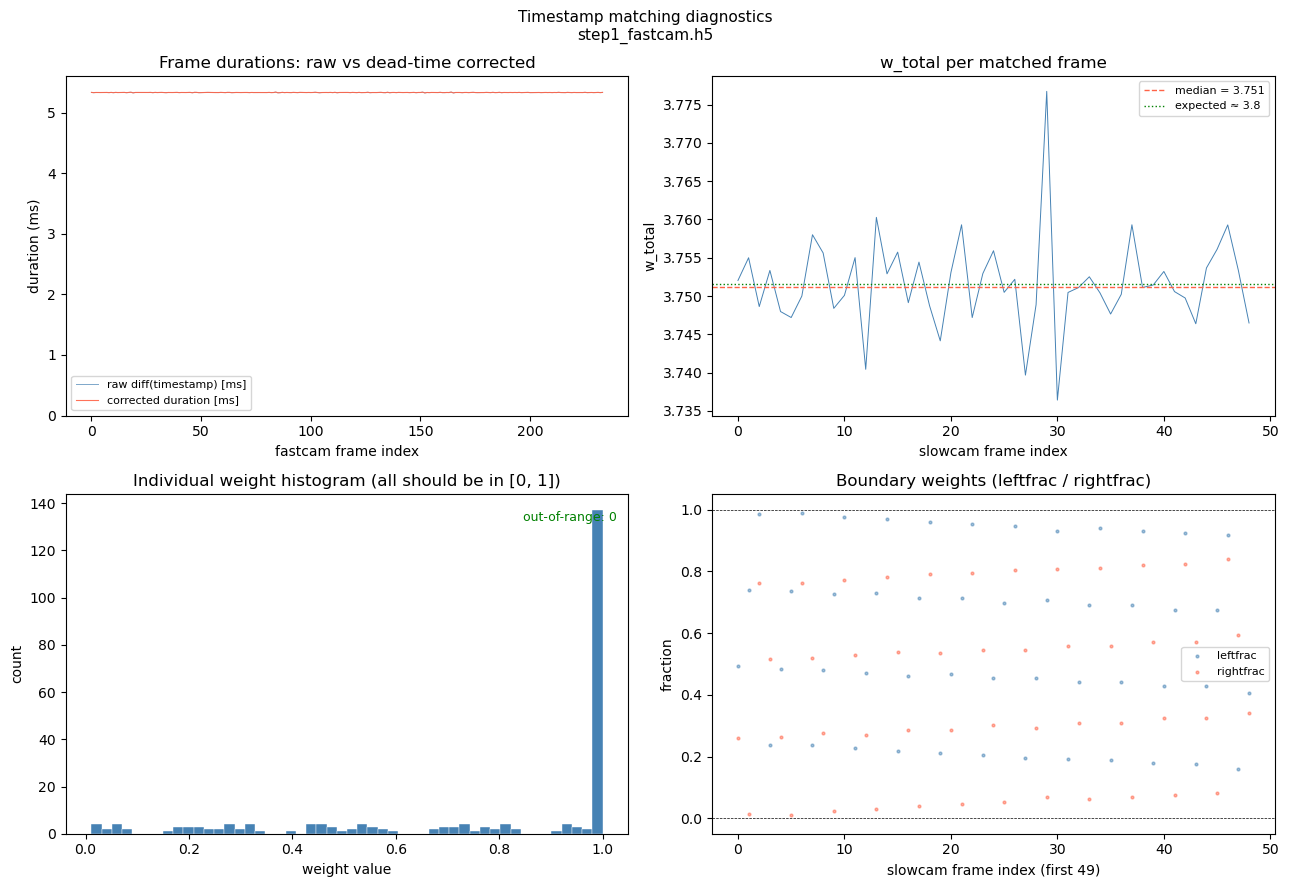

In [12]:
# From a Python script or terminal session:
import PLred.sort as sort
sort.script_match_timestamps('tutorial_output_new/step1_config.ini')

The pipeline runner reads a single unified `obs.ini` that contains sections for all steps (`[Fastcam]`, `[Slowcam]`, `[Ingest]`, `[Average]`, `[Specextract]`). This is convenient for batch runs on a cluster or when you want to rerun a specific step without opening a notebook.

See `obs.ini` for an example of a complete unified config file.

Below script uses the unified config file.


=== Step 1: Timestamp matching (plred-sort) ===
number of files found: 1
total slowcam images: 49
Applied dead-time correction using frame end times


100%|██████████| 49/49 [00:00<00:00, 118866.91it/s]


PSFcam=fastcam — saving cropped frames [108:148, 140:180]
reading fastcam file /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/data/fastcam/cropped_palila_15:05:10.002607418.fits


100%|██████████| 49/49 [00:00<00:00, 6634.20it/s]

saved: /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/tutorial_output/fastcam.h5  (49 frames)
timestamp matching backup saved to /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/tutorial_output/fastcam.pkl


Diagnostics saved to /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/tutorial_output/fastcam_diagnostics.png
=== Diagnostic summary: fastcam.h5 ===
fastcam frames:         235  (1 files)
slowcam matched frames: 49
Weight range: [0.0112, 1.0000]  (out-of-range: 0)
w_total: median=3.751  min=3.736  max=3.777
Diagnostic saved: /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/plots/1_sort.png
number of files found: 1
Diagnostic saved: /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/plots/1_first_frame.png


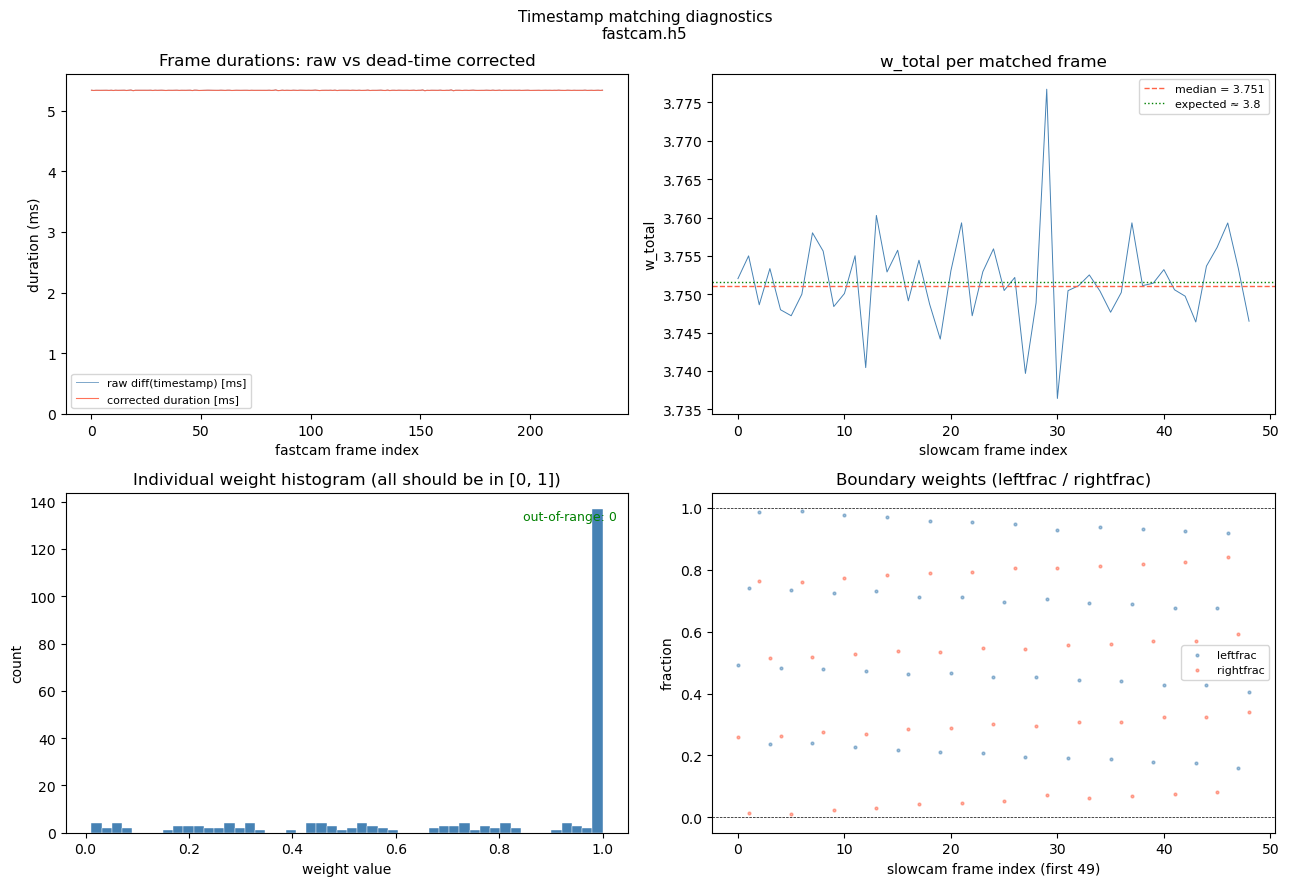

In [14]:
# Or using the high-level pipeline runner (runs all steps in sequence):
import PLred.pipeline as pipeline
pipeline.run_mode1('obs.ini', steps=[1])   # run only Step 1

## CLI equivalent

Run in the terminal,

```
plred-sort tutorial_output_new/step1_config.ini
```